# 🐍 Python Level 2 - Intermediate course
## Class 2 — Comprehensions and Built-in Functions

**Python instructor - Luis Dias**

---

<div style="display:inline-flex; align-items:center; gap:28px; background:#FFFFFF; color:#1D1D1B; padding:10px 14px; border-radius:8px; margin-bottom:8px;">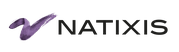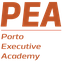</div>

---

---

### 📋 What we'll cover today

| # | Topic |
|---|-------|
| 1 | Why comprehensions? |
| 2 | List comprehensions |
| 3 | Dict and set comprehensions |
| 4 | `lambda` — a function with no name |
| 5 | `sorted()` with a key |
| 6 | `map`, `filter`, `zip`, `any`, `all` |
| 7 | 🔗 Putting it all together |

### 🎯 Learning outcomes

By the end of this class you will be able to:

- Replace a build-a-list loop with a single readable line
- Build dictionaries and sets the same way
- Sort by anything you like, not just the value itself
- Use Python's built-in helpers instead of writing them yourself

---

> 💡 Nothing today lets you do something you could not already do. Everything today lets you
> say it in **one line instead of four** and one line you can read at a glance is worth a lot
> when you come back to it in three months.

---
## 1. Why comprehensions?

In Level 1 you wrote this shape over and over: make an empty list, loop, append.

Look at the two versions below. They produce exactly the same list.

In [28]:
products = [
    {"name": "Coffee",    "price": 8.50, "category": "Drinks",  "in_stock": True},
    {"name": "Tea",       "price": 4.20, "category": "Drinks",  "in_stock": True},
    {"name": "Sugar",     "price": 2.10, "category": "Baking",  "in_stock": False},
    {"name": "Milk",      "price": 1.15, "category": "Drinks",  "in_stock": True},
    {"name": "Olive oil", "price": 8.75, "category": "Cooking", "in_stock": False},
]

In [33]:
# ── The way you already know: empty list, loop, append ────────────────────
names = []
for product in products:
  if len(product["name"])>4:
    names.append(product["name"])

In [34]:
print(names)

['Coffee', 'Sugar', 'Olive oil']


In [31]:
# ── The same thing as a comprehension ─────────────────────────────────────
names = [product["name"] for product in products]

In [32]:
print(names)

['Coffee', 'Tea', 'Sugar', 'Milk', 'Olive oil']


Four lines became one, and the one line reads left to right as a sentence: *"the name of each
product, for every product in products."*

A comprehension is the right tool when you are **building a new list from an old one**. It is
the wrong tool when the loop does several things, or prints, or updates a running total. Readability is the whole point, so if a comprehension is harder
to read than the loop, use the loop.

---
## 2. List comprehensions

Three parts, always in the same order:

```
   [ price * 2  for price in prices  if price > 10 ]
     └───┬───┘  └────────┬────────┘  └─────┬─────┘
      what to        for each          only when
       keep         item in it        this is True
```

- **what to keep** — the value that goes into the new list. It can be the item itself, a field
  of it, or a calculation on it.
- **for each item** — exactly like a normal `for` loop.
- **only when** — optional. Leave it out and you keep everything.

Read one aloud starting from the middle: *"for every price in prices, if it is over 10, keep
price times 2."* That is the order Python does it in, too.

| You want | Write |
|----------|-------|
| Every item, unchanged | `[p for p in prices]` |
| One field of each | `[p["name"] for p in products]` |
| A calculation on each | `[p * 1.23 for p in prices]` |
| Only some of them | `[p for p in prices if p > 5]` |
| Both at once | `[p * 1.23 for p in prices if p > 5]` |

In [35]:
prices = [8.50, 4.20, 2.10, 1.15, 8.75]

In [36]:
# A calculation on every item
with_vat = [round(price * 1.23, 2) for price in prices]
print(with_vat)

[10.46, 5.17, 2.58, 1.41, 10.76]


In [38]:
# Only the items that pass a test
cheap = [price for price in prices if price < 2]
print(cheap)

[1.15]


In [39]:
# Both: transform, and only for some
cheap_with_vat = [round(price * 1.23, 2) for price in prices if price < 5]
print(cheap_with_vat)

[5.17, 2.58, 1.41]


In [40]:
products

[{'name': 'Coffee', 'price': 8.5, 'category': 'Drinks', 'in_stock': True},
 {'name': 'Tea', 'price': 4.2, 'category': 'Drinks', 'in_stock': True},
 {'name': 'Sugar', 'price': 2.1, 'category': 'Baking', 'in_stock': False},
 {'name': 'Milk', 'price': 1.15, 'category': 'Drinks', 'in_stock': True},
 {'name': 'Olive oil',
  'price': 8.75,
  'category': 'Cooking',
  'in_stock': False}]

In [41]:
# The same works on a list of dicts
in_stock = [product["name"] for product in products if product["in_stock"]]
print(in_stock)

['Coffee', 'Tea', 'Milk']


---
## 3. Dict and set comprehensions

The same idea with different brackets.

| Brackets | You get | Shape |
|----------|---------|-------|
| `[ ... ]` | a **list** | `[value for item in things]` |
| `{ ... : ... }` | a **dict** | `{key: value for item in things}` |
| `{ ... }` | a **set** | `{value for item in things}` |

A **dict comprehension** needs two expressions with a colon between them, namely the key and the
value. A **set comprehension** looks like a list one but with curly brackets, and gives you the
unique values, as sets always do.

> 💡 The dict comprehension is the one you will reach for most: turning a list of records into
> a lookup table keyed by name or id is a job that comes up constantly, and it used to take
> four lines.

In [42]:
# A dict comprehension: name -> price, a lookup table in one line
price_list = {product["name"]: product["price"] for product in products}
print(price_list)

{'Coffee': 8.5, 'Tea': 4.2, 'Sugar': 2.1, 'Milk': 1.15, 'Olive oil': 8.75}


In [43]:
print(price_list["Tea"])            # now we can look prices up by name

4.2


In [44]:
# With a condition, like any comprehension
cheap_list = {p["name"]: p["price"] for p in products if p["price"] < 5}
print(cheap_list)

{'Tea': 4.2, 'Sugar': 2.1, 'Milk': 1.15}


In [45]:
this_is_a_set = {"Ana", "Pedro", "Filipa", "Ana"}

In [46]:
this_is_a_set

{'Ana', 'Filipa', 'Pedro'}

In [47]:
# A set comprehension: the distinct categories, no duplicates
categories = {product["category"] for product in products}
print(sorted(categories))

['Baking', 'Cooking', 'Drinks']


---
## 4. `lambda` — a function with no name

A **lambda** is a function small enough to write on one line, used where giving it a name would
be more trouble than it is worth.

| Written as a `def` | Written as a lambda |
|--------------------|--------------------|
| `def double(x):`<br>`    return x * 2` | `double = lambda x: x * 2` |

The parts are: the word `lambda`, the parameter names, a colon, and **one expression** whose
value is returned. There is no `return` keyword since the expression *is* the result.

> ⚠️ A lambda holds **one expression** only. No `if` blocks, no loops, no several lines. The
> moment you want any of those, write a `def`.

> 💡 You will rarely assign a lambda to a name like the table above. If it deserves a name, it
> deserves a `def`. Lambdas earn their keep when they are handed **to** another function, which
> is exactly what the next two sections do.

In [48]:
# The same job, two ways
def double_def(x):
    """Return twice x."""
    return x * 2

In [50]:
natixis = lambda x: x * 3

In [51]:
print(double_def(5), natixis(5))

10 15


In [53]:
# More than one parameter is fine
line_total = lambda price, vat: round(price * (1+vat), 2)
print(line_total(8.50, 0.06))

9.01


In [54]:
sorted(prices)

[1.15, 2.1, 4.2, 8.5, 8.75]

In [57]:
sorted(prices,reverse=False)

[1.15, 2.1, 4.2, 8.5, 8.75]

In [58]:
# Where lambdas actually belong: handed to another function (section 5)
print(sorted(prices, key=lambda price: -price))

[8.75, 8.5, 4.2, 2.1, 1.15]


In [59]:
names = [product["name"] for product in products]
names

['Coffee', 'Tea', 'Sugar', 'Milk', 'Olive oil']

In [60]:
print(sorted(names))

['Coffee', 'Milk', 'Olive oil', 'Sugar', 'Tea']


In [61]:
print(sorted(names, reverse=True))

['Tea', 'Sugar', 'Olive oil', 'Milk', 'Coffee']


In [62]:
print(sorted(names, key=lambda name: len(name)))

['Tea', 'Milk', 'Sugar', 'Coffee', 'Olive oil']


In [63]:
print(sorted(names, key=lambda name: -len(name)))

['Olive oil', 'Coffee', 'Sugar', 'Milk', 'Tea']


---
## 5. `sorted()` with a key

You already use `sorted()`. Two extras make it do almost anything.

| Extra | Does |
|-------|------|
| `reverse=True` | biggest first instead of smallest |
| `key=...` | sort by **something derived from** each item, not the item itself |

`key` takes a function, and Python calls it once per item to work out what to sort **on**. This
is what lets you sort a list of dictionaries. The dict itself has no order, but
`key=lambda p: p["price"]` says *"sort these by their price"*.

| You want | Write |
|----------|-------|
| Prices, smallest first | `sorted(prices)` |
| Prices, biggest first | `sorted(prices, reverse=True)` |
| Products by price | `sorted(products, key=lambda p: p["price"])` |
| Products by name | `sorted(products, key=lambda p: p["name"])` |
| The 3 dearest products | `sorted(products, key=lambda p: p["price"], reverse=True)[:3]` |

> 💡 `sorted()` always hands back a **new** list and leaves the original alone so you can sort
> the same data three different ways without disturbing it.

In [66]:
print(sorted(prices))                    # smallest first

[1.15, 2.1, 4.2, 8.5, 8.75]


In [67]:
print(sorted(prices, reverse=True))         # biggest first

[8.75, 8.5, 4.2, 2.1, 1.15]


In [68]:
products

[{'name': 'Coffee', 'price': 8.5, 'category': 'Drinks', 'in_stock': True},
 {'name': 'Tea', 'price': 4.2, 'category': 'Drinks', 'in_stock': True},
 {'name': 'Sugar', 'price': 2.1, 'category': 'Baking', 'in_stock': False},
 {'name': 'Milk', 'price': 1.15, 'category': 'Drinks', 'in_stock': True},
 {'name': 'Olive oil',
  'price': 8.75,
  'category': 'Cooking',
  'in_stock': False}]

In [69]:
# Sorting dictionaries: the key says what to sort ON
by_price = sorted(products, key=lambda product: product["price"])
print([product["name"] for product in by_price])

['Milk', 'Sugar', 'Tea', 'Coffee', 'Olive oil']


In [70]:
by_price

[{'name': 'Milk', 'price': 1.15, 'category': 'Drinks', 'in_stock': True},
 {'name': 'Sugar', 'price': 2.1, 'category': 'Baking', 'in_stock': False},
 {'name': 'Tea', 'price': 4.2, 'category': 'Drinks', 'in_stock': True},
 {'name': 'Coffee', 'price': 8.5, 'category': 'Drinks', 'in_stock': True},
 {'name': 'Olive oil',
  'price': 8.75,
  'category': 'Cooking',
  'in_stock': False}]

In [71]:
prices_wrong = ["coffe", "tea"]

In [73]:
by_price = sorted(prices_wrong, key=lambda product: product[1])

In [ ]:
by_name = sorted(products, key=lambda product: product["name"])
print([product["name"] for product in by_name])

In [87]:
# The two dearest: sort biggest first, then take a slice
dearest = sorted(products, key=lambda product: product["price"], reverse=True)[-1]
print([product["name"] for product in dearest])

TypeError: string indices must be integers, not 'str'

In [75]:
dearest

[{'name': 'Olive oil',
  'price': 8.75,
  'category': 'Cooking',
  'in_stock': False},
 {'name': 'Coffee', 'price': 8.5, 'category': 'Drinks', 'in_stock': True}]

In [86]:
prices[-1]

8.75

---
## 6. `map`, `filter`, `zip`, `any`, `all`

Five built-ins that do jobs you would otherwise write a loop for.

### `map` and `filter`

`map(function, things)` runs the function on **every** item. `filter(function, things)` keeps
the items where the function says `True`. Both need `list(...)` around them to become a real
list you can print.

```
   prices = [8.50, 4.20, 2.10]
        │
        ▼
   filter(...)          keep some of them
        │
        ▼
   map(...)             change each one
        │
        ▼
   list(...)            make it a real list
```

> 💡 A list comprehension does both jobs and most Python programmers find it easier to read —
> `[p * 1.23 for p in prices if p < 5]` versus a `map` wrapped around a `filter`. Learn `map`
> and `filter` because you will meet them in other people's code; reach for the comprehension
> in your own.

### `zip`, `any` and `all`

| Built-in | Answers |
|----------|---------|
| `zip(a, b)` | pairs up two lists, item by item |
| `any(tests)` | is **at least one** of these True? |
| `all(tests)` | are **all** of these True? |

`any` and `all` take a list of `True`/`False` values — which a comprehension is very good at
producing.

In [88]:
# map: change every item.  filter: keep some.
print(list(map(lambda price: round(price * 1.23, 2), prices)))

[10.46, 5.17, 2.58, 1.41, 10.76]


In [90]:
map(lambda price: round(price * 1.23, 2), prices)

In [89]:
print(list(filter(lambda price: price < 5, prices)))

[4.2, 2.1, 1.15]


In [91]:
# The same two jobs as one comprehension - usually the clearer choice
print([round(price * 1.23, 2) for price in prices if price < 5])

[5.17, 2.58, 1.41]


In [95]:
names = ["Coffee", "Tea", "Sugar"]
amounts = [8.50, 4.20, 2.10]
vat_list = [0.06, 0.23, 0]

In [96]:
# zip: walk two lists together
for name, amount, vat in zip(names, amounts, vat_list):
    print(f"{name:<8}{amount:>6.2f} EUR  {vat} VAT")

Coffee    8.50 EUR  0.06 VAT
Tea       4.20 EUR  0.23 VAT
Sugar     2.10 EUR  0 VAT


In [101]:
# any / all, fed by a comprehension
stock_flags = [product["in_stock"] for product in products]
print(stock_flags)

[True, True, False, True, False]


In [98]:
print("Anything in stock? ", any(stock_flags))

Anything in stock?  True


In [99]:
stock_flags = [False, False, False]

In [100]:
print("Anything in stock? ", any(stock_flags))

Anything in stock?  False


In [102]:
print("Everything in stock?", all(stock_flags))

Everything in stock? False


In [104]:
[price > 8 for price in prices]

[True, False, False, False, True]

In [105]:
print("Anything over 8 EUR?", any(price > 8 for price in prices))

Anything over 8 EUR? True


---
## 7. 🔗 Putting it all together — price list summary

Everything from today, on one screen.

### The situation

You have the product list from section 1. The shop wants a one-page summary: what is available,
what it costs with VAT, the cheapest and dearest items, and a quick check on stock.

### What the program must do

1. A **list** of the names that are in stock — a comprehension with a condition
2. A **dict** of name → price including VAT at 23% — a dict comprehension
3. A **set** of the distinct categories — a set comprehension
4. The products sorted by price, and the two dearest — `sorted` with a `lambda` key
5. The total and average price — `sum`, `len`, `round`
6. Two stock checks — `any` and `all` over a comprehension
7. A printed table pairing names with prices — `zip`

### Where each concept appears

| Concept from today | Where it is used |
|--------------------|------------------|
| List comprehension | the in-stock names, the price values |
| Condition in a comprehension | `if product["in_stock"]` |
| Dict comprehension | the VAT price list |
| Set comprehension | the distinct categories |
| `lambda` | the `sorted` keys |
| `sorted` with `key` and `reverse` | cheapest first, and the two dearest |
| `zip` | pairing names with prices for the table |
| `any` / `all` | the stock checks |
| `sum`, `len`, `round`, f-strings | from Level 1 |

In [ ]:
VAT_RATE = 1.23

# ── 1-3. Three comprehensions, three different brackets ───────────────────
available = [product["name"] for product in products if product["in_stock"]]
with_vat = {p["name"]: round(p["price"] * VAT_RATE, 2) for p in products}
categories = {product["category"] for product in products}

In [ ]:
# ── 4. Sorting by something derived from each item ─────────────────────────
by_price = sorted(products, key=lambda product: product["price"])
dearest = sorted(products, key=lambda product: product["price"], reverse=True)[:2]

In [ ]:
# ── 5. Totals, from a comprehension of the prices ─────────────────────────
prices = [product["price"] for product in products]
total = round(sum(prices), 2)
average = round(total / len(prices), 2)

In [ ]:
# ── 6. Two checks, each over a comprehension ──────────────────────────────
all_available = all(product["in_stock"] for product in products)
any_pricey = any(product["price"] > 8 for product in products)

In [ ]:
# ── 7. The report: two separate lists, walked together with zip ───────────
names = [product["name"] for product in products]
vat_prices = [with_vat[name] for name in names]    # the dict earns its keep here

In [ ]:
print("PRICE LIST (including VAT)")
print("-" * 34)

for name, price in zip(names, vat_prices):
    print(f"{name:<12}{price:>8.2f} EUR")

print("-" * 34)
print(f"Products      : {len(products)}")
print(f"In stock      : {len(available)} -> {available}")
print(f"Categories    : {sorted(categories)}")
print(f"Cheapest      : {by_price[0]['name']}")
print(f"Two dearest   : {[product['name'] for product in dearest]}")
print(f"Total / avg   : {total:.2f} / {average:.2f} EUR")
print(f"All in stock? : {all_available}")
print(f"Any over 8?   : {any_pricey}")

---

### 🎉 That's Level 2 Class 2!

| Concept | Key syntax |
|---------|-----------|
| List comprehension | `[value for item in things]` |
| …with a condition | `[value for item in things if test]` |
| …with a calculation | `[item * 2 for item in things]` |
| Dict comprehension | `{key: value for item in things}` |
| Set comprehension | `{value for item in things}` |
| Lambda | `lambda x: x * 2` |
| Sort biggest first | `sorted(things, reverse=True)` |
| Sort by a field | `sorted(things, key=lambda t: t["price"])` |
| Run on every item | `list(map(function, things))` |
| Keep some items | `list(filter(function, things))` |
| Walk two lists together | `zip(names, prices)` |
| At least one True? | `any(tests)` |
| All True? | `all(tests)` |

> 💡 **The rule for using them:** a comprehension should be *easier* to read than the loop it
> replaces. One `for` and at most one `if` is comfortable. Two `for`s, or an `if` inside the
> value as well as after it, and you have written something only you will ever understand then
> use a loop.

➡️ Now open the **exercises notebook**.